# Electricity Consumption Forecasting — Part 1
**Author:** Jaya Sai Kishore  
**Goal:** Forecast 96 electricity values (every 15 min) for 2010-02-19  
**Dataset:** `Elec-train.xlsx` — Power (kW) and Temperature (°C), Jan 1 – Feb 18, 2010

### Notebook Flow
1. Imports  
2. Load & Clean Data  
3. Exploratory Data Analysis (EDA)  
4. Train / Validation Split (same split for ALL models)  
5. Feature Engineering (for ML models)  
6. Model 1 — Seasonal Naïve Baseline  
7. Model 2 — Exponential Smoothing (ETS)  
8. Model 3 — SARIMA  
9. Model 4 — Random Forest  
10. Model 5 — SVM (SVR)  
11. Model 6 — Neural Network (MLP)  
12. Model 7 — XGBoost  
13. Model 8 — LSTM  
14. Model Comparison  
15. Final Forecast → `JayaSaiKishore.xlsx`

## Step 1 — Imports
All libraries loaded once at the top. Never repeated inside model cells.

In [7]:
# ── suppress noisy warnings so output stays clean ────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── core data libraries ───────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
from pathlib import Path
from math    import sqrt

# ── plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"]      = True

# ── metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── classical time-series models ──────────────────────────────────────────────
from statsmodels.tsa.holtwinters        import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── machine-learning models ───────────────────────────────────────────────────
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline       import make_pipeline
from sklearn.ensemble       import RandomForestRegressor
from sklearn.svm            import SVR
from sklearn.neural_network import MLPRegressor

# ── gradient boosting ─────────────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── deep learning (LSTM) ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


## Step 2 — Global Constants

In [8]:
HORIZON = 96    # 96 steps × 15 min = one full day  → our forecast length
SEASON  = 96    # seasonal period = 1 day (96 quarter-hourly slots)

## Step 3 — Load & Clean Data
- Parse timestamps  
- Rename columns for easy typing  
- Split into **`df_train`** (power known, Jan 1 – Feb 18) and **`df_future`** (power = NaN, Feb 19)

In [9]:
# ── load raw file ─────────────────────────────────────────────────────────────
df_raw = pd.read_excel("../data/Elec-train.xlsx")

# ── parse timestamp column ────────────────────────────────────────────────────
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"])

# ── rename for convenience ────────────────────────────────────────────────────
df_raw = df_raw.rename(columns={
    "Power (kW)": "Power",
    "Temp (C°)":  "Temp"
})

# ── sort by time and set as index ─────────────────────────────────────────────
df_raw = df_raw.sort_values("Timestamp").set_index("Timestamp")

# ── split known data vs rows to forecast ─────────────────────────────────────
#    df_train  : Jan 1 → Feb 18  (Power is known)
#    df_future : Feb 19 only     (Power is NaN — this is what we must predict)
df_train  = df_raw[df_raw["Power"].notna()].copy()
df_future = df_raw[df_raw["Power"].isna() ].copy()

print(f"Training rows : {len(df_train):,}  ({df_train.index.min().date()} → {df_train.index.max().date()})")
print(f"Forecast rows : {len(df_future):,}  ({df_future.index.min().date()} → {df_future.index.max().date()})")
print()
print("Missing values in training data:")
print(df_train.isna().sum())
print()
df_train.head()

Training rows : 4,699  (2010-01-01 → 2010-02-18)
Forecast rows : 96  (2010-02-19 → 2010-02-19)

Missing values in training data:
Power    0
Temp     0
dtype: int64



,Power,Temp
Timestamp,,
2010-01-01 01:15:00,165.1,10.555556
2010-01-01 01:30:00,151.6,10.555556
2010-01-01 01:45:00,146.9,10.555556
2010-01-01 02:00:00,153.7,10.555556
2010-01-01 02:15:00,153.8,10.555556


## Step 4 — Exploratory Data Analysis (EDA)
We visualise the series before modelling to understand:
- Overall level and daily cycles  
- Weekly patterns (weekday vs weekend)  
- Relationship between temperature and power

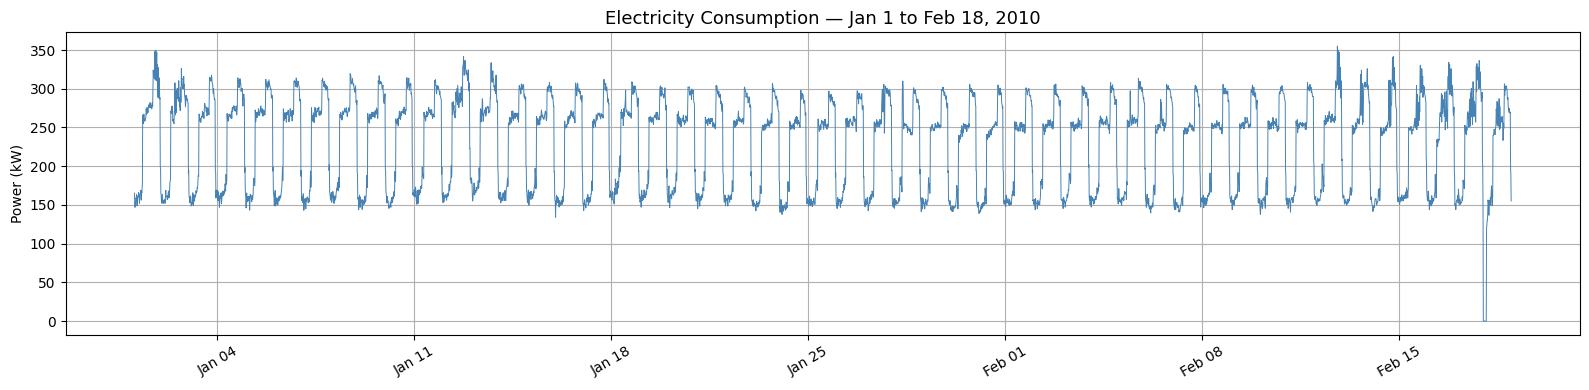

In [10]:
# ── Plot 1: Full power consumption series ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_train.index, df_train["Power"], linewidth=0.7, color="steelblue")
ax.set_title("Electricity Consumption — Jan 1 to Feb 18, 2010", fontsize=13)
ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

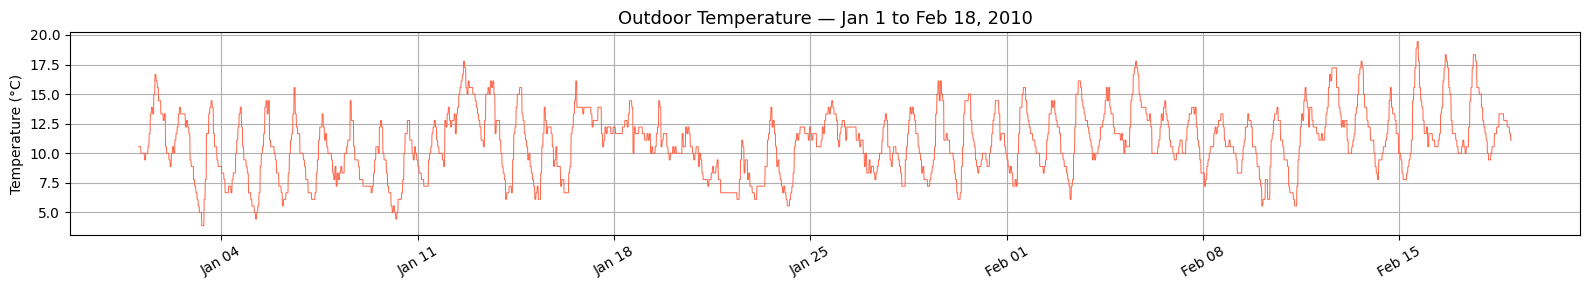

In [11]:
# ── Plot 2: Outdoor temperature series ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(df_train.index, df_train["Temp"], linewidth=0.7, color="tomato")
ax.set_title("Outdoor Temperature — Jan 1 to Feb 18, 2010", fontsize=13)
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

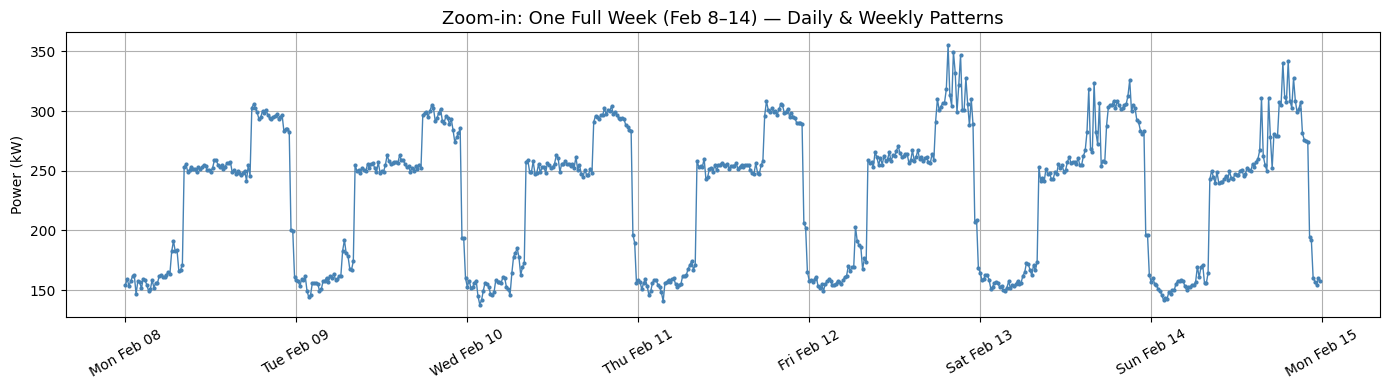

In [12]:
# ── Plot 3: One-week zoom to inspect daily + weekly patterns ─────────────────
one_week = df_train["2010-02-08":"2010-02-14"]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one_week.index, one_week["Power"],
        marker="o", markersize=2, linewidth=1, color="steelblue")
ax.set_title("Zoom-in: One Full Week (Feb 8–14) — Daily & Weekly Patterns", fontsize=13)
ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
# Key observation: strong 96-step daily cycle; lower on weekends

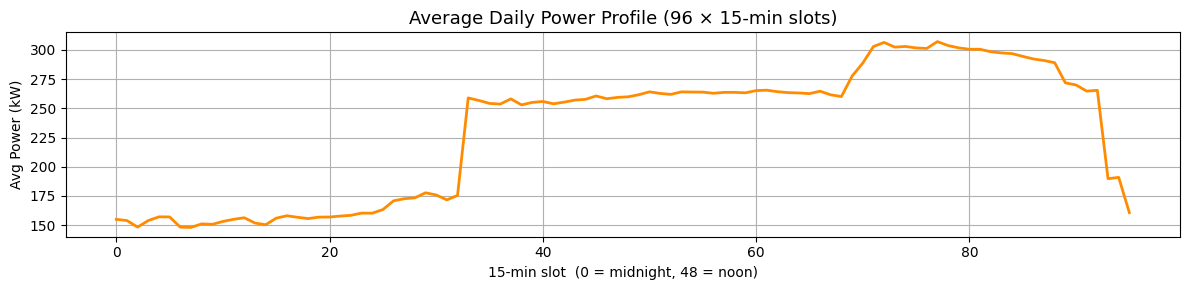

In [13]:
# ── Plot 4: Average power for each of the 96 daily slots ─────────────────────
df_train_plot = df_train.copy()
df_train_plot["slot"] = df_train_plot.index.hour * 4 + df_train_plot.index.minute // 15
avg_profile = df_train_plot.groupby("slot")["Power"].mean()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(avg_profile.index, avg_profile.values, color="darkorange", linewidth=2)
ax.set_title("Average Daily Power Profile (96 × 15-min slots)", fontsize=13)
ax.set_xlabel("15-min slot  (0 = midnight, 48 = noon)")
ax.set_ylabel("Avg Power (kW)")
plt.tight_layout()
plt.show()
# Key observation: clear work-hours peak ~8 am to 3 pm

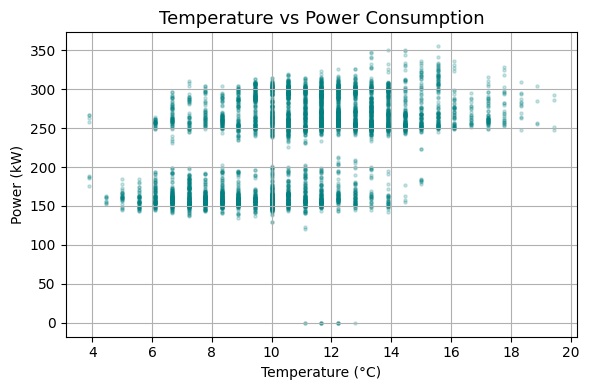

In [14]:
# ── Plot 5: Temperature vs Power scatter ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df_train["Temp"], df_train["Power"],
           alpha=0.2, s=5, color="teal")
ax.set_title("Temperature vs Power Consumption", fontsize=13)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Power (kW)")
plt.tight_layout()
plt.show()
# Key observation: mild negative correlation — colder → slightly higher power

## Step 5 — Train / Validation Split
**IMPORTANT:** Every single model uses the **same** validation set so results are comparable.  
We hold out the **last 96 known points (Feb 18, 2010)** as validation — this exactly mimics  
the exam task (forecast one full day ahead).

In [15]:
# ── univariate series (power only) ───────────────────────────────────────────
y_all = df_train["Power"]

# ── hold out last 96 points as validation (Feb 18) ───────────────────────────
y_val   = y_all.iloc[-HORIZON:]      # validation: last 96 steps (Feb 18)
y_train = y_all.iloc[:-HORIZON]      # training : everything before Feb 18

print(f"Training  : {len(y_train):,} points  "
      f"({y_train.index[0].date()} → {y_train.index[-1].date()})")
print(f"Validation: {len(y_val):,}  points  "
      f"({y_val.index[0].date()} → {y_val.index[-1].date()})")

Training  : 4,603 points  (2010-01-01 → 2010-02-17)
Validation: 96  points  (2010-02-18 → 2010-02-18)


## Step 6 — Helper Functions
`evaluate()` — prints MAE + RMSE and stores them for the final comparison table  
`build_features()` — creates the supervised-learning feature table for ML models

In [16]:
# ── results tracker ───────────────────────────────────────────────────────────
all_results = []   # every model appends {"Model":..., "MAE":..., "RMSE":...}

def evaluate(y_true, y_pred, model_name):
    """
    Compute MAE and RMSE, print them, and store in all_results.

    Parameters
    ----------
    y_true     : array-like  — actual values
    y_pred     : array-like  — predicted values
    model_name : str         — label for the comparison table
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {model_name:<38}  MAE={mae:7.2f}   RMSE={rmse:7.2f}")
    all_results.append({"Model": model_name,
                        "MAE" : round(mae,  3),
                        "RMSE": round(rmse, 3)})

In [17]:
def build_features(df_source, lags=(1, 2, 3, 96, 672)):
    """
    Convert a Power+Temp dataframe into a supervised ML feature table.

    Features created
    ----------------
    hour, minute, dayofweek, is_weekend, slot  — calendar / time-of-day
    Temp                                        — outdoor temperature
    lag_1, lag_2, lag_3, lag_96, lag_672        — past power values
    roll_mean_96                                — rolling previous-day average

    Parameters
    ----------
    df_source : pd.DataFrame  — must have 'Power' and 'Temp', datetime index
    lags      : tuple of int  — which lag steps to create

    Returns
    -------
    pd.DataFrame  — all features + Power target; NaN rows removed
    """
    df = df_source.copy()

    # calendar features
    df["hour"]       = df.index.hour
    df["minute"]     = df.index.minute
    df["dayofweek"]  = df.index.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["slot"]       = df["hour"] * 4 + df["minute"] // 15

    # lag features — power value n steps in the past
    for lag in lags:
        df[f"lag_{lag}"] = df["Power"].shift(lag)

    # rolling mean of the previous 96 steps (1 full day)
    df["roll_mean_96"] = df["Power"].shift(1).rolling(window=96).mean()

    return df.dropna()   # drop rows where any lag is NaN

print("Helper functions ready ✓")

Helper functions ready ✓


## Model 1 — Seasonal Naïve Baseline
**Idea:** Simply repeat the power values from exactly 7 days ago (7 × 96 = 672 steps back).  
This is the simplest possible seasonality-aware forecast. Every model must beat this.

Model 1 — Seasonal Naïve Baseline
  Seasonal Naive (7-day repeat)           MAE=  27.77   RMSE=  54.07


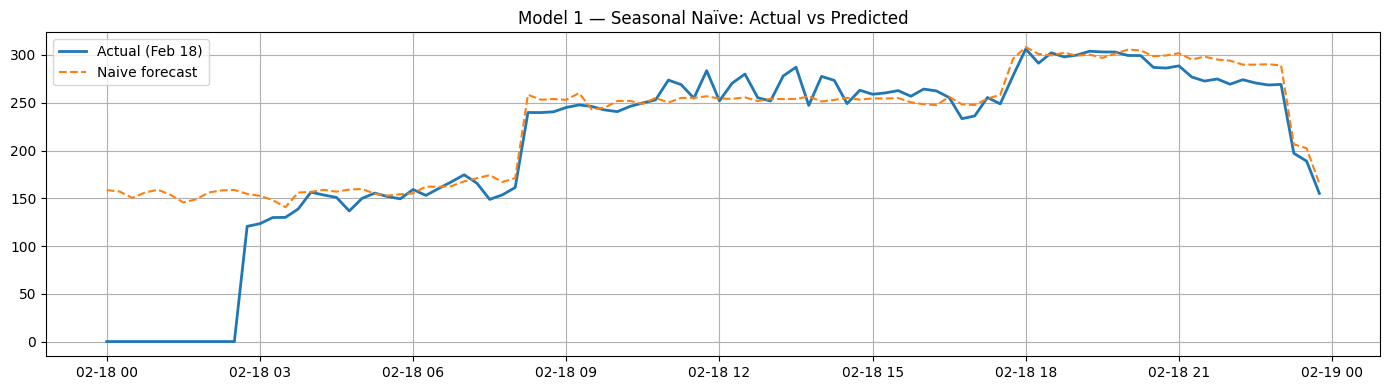

In [18]:
# 672 steps back = exactly one week ago — a strong baseline for electricity
y_pred_naive = y_train.iloc[-672 : -672 + HORIZON].values

print("Model 1 — Seasonal Naïve Baseline")
evaluate(y_val, y_pred_naive, "Seasonal Naive (7-day repeat)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val.index, y_val.values,   label="Actual (Feb 18)",  linewidth=2)
ax.plot(y_val.index, y_pred_naive,   label="Naive forecast",   linewidth=1.5, linestyle="--")
ax.set_title("Model 1 — Seasonal Naïve: Actual vs Predicted")
ax.legend(); plt.tight_layout(); plt.show()

## Model 2 — Exponential Smoothing (ETS)
**Idea:** Holt-Winters ETS decomposes the series into level, trend and seasonal components  
and forecasts by exponentially weighting recent observations.  
Seasonal period = 96 (one full day of 15-min slots).  
`optimized=True` automatically tunes the smoothing parameters α, β, γ.

Model 2 — Exponential Smoothing (ETS)
  Exponential Smoothing (ETS)             MAE=  25.43   RMSE=  51.55


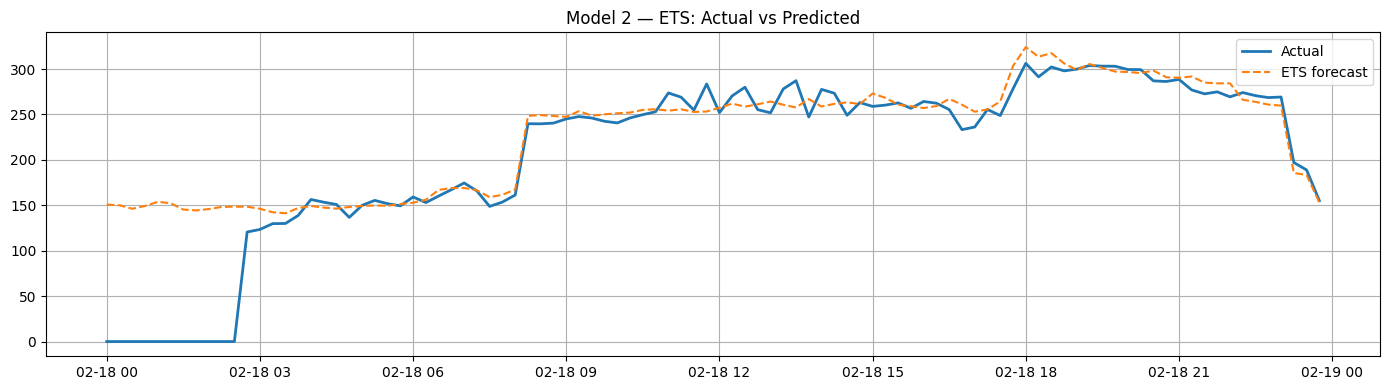

In [19]:
# ── fit ETS with additive trend + additive seasonality ───────────────────────
ets_model = ExponentialSmoothing(
    y_train,
    trend            = "add",   # additive trend component
    seasonal         = "add",   # additive seasonal component
    seasonal_periods = SEASON,  # 96 steps = 1 day
    initialization_method = "estimated"
).fit(optimized=True)           # auto-tune alpha, beta, gamma

y_pred_ets = ets_model.forecast(HORIZON).values

print("Model 2 — Exponential Smoothing (ETS)")
evaluate(y_val, y_pred_ets, "Exponential Smoothing (ETS)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val.index, y_val.values, label="Actual",       linewidth=2)
ax.plot(y_val.index, y_pred_ets,   label="ETS forecast", linewidth=1.5, linestyle="--")
ax.set_title("Model 2 — ETS: Actual vs Predicted")
ax.legend(); plt.tight_layout(); plt.show()

## Model 3 — SARIMA
**Idea:** Seasonal ARIMA combines autoregression, differencing, and moving-average  
components at both regular and seasonal lags.  
We **resample to hourly** to keep fitting time reasonable (s=24 instead of s=96),  
then **repeat each hourly forecast 4×** to get back to 96 quarter-hourly values.

**Hyperparameter tuning:** we try 4 common (p,d,q) combinations and pick the best.

SARIMA hyperparameter search:
  order=(1, 0, 0)  seasonal=(1,1,0,24)  MAE=32.70
  order=(1, 1, 0)  seasonal=(1,1,0,24)  MAE=34.12
  order=(1, 0, 1)  seasonal=(1,1,0,24)  MAE=32.61
  order=(1, 1, 1)  seasonal=(1,1,0,24)  MAE=32.64

Best SARIMA order: (1, 0, 1)

Model 3 — SARIMA
  SARIMA (1, 0, 1)(1,1,0)[24]             MAE=  32.61   RMSE=  56.54


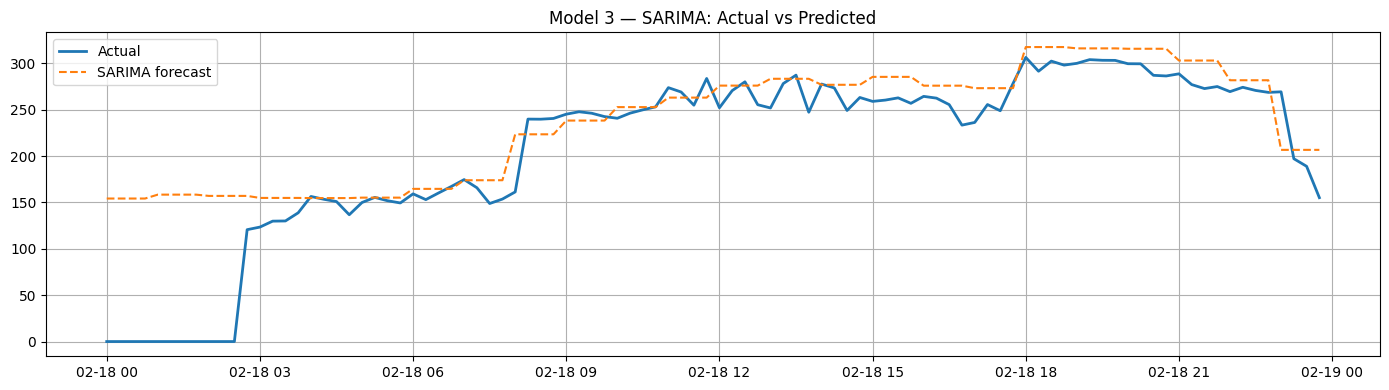

In [20]:
# ── resample training and validation to hourly ────────────────────────────────
y_train_h = y_train.resample("1h").mean()   # 4 × 15-min → 1 hour
y_val_h   = y_val.resample("1h").mean()     # 96 points  → 24 hourly points

# ── hyperparameter search over (p, d, q) ──────────────────────────────────────
sarima_candidates = [
    (1, 0, 0),
    (1, 1, 0),
    (1, 0, 1),
    (1, 1, 1),
]

best_sarima_mae  = float("inf")
best_sarima_order = None
best_sarima_fit   = None

print("SARIMA hyperparameter search:")
for order in sarima_candidates:
    try:
        fit = SARIMAX(
            y_train_h,
            order          = order,
            seasonal_order = (1, 1, 0, 24),   # seasonal AR + differencing, s=24h
            enforce_stationarity  = False,
            enforce_invertibility = False
        ).fit(disp=False)

        preds_h = fit.forecast(24)
        preds   = np.repeat(preds_h.values, 4)   # back to 96 quarter-hourly
        mae     = mean_absolute_error(y_val, preds)

        print(f"  order={order}  seasonal=(1,1,0,24)  MAE={mae:.2f}")

        if mae < best_sarima_mae:
            best_sarima_mae   = mae
            best_sarima_order = order
            best_sarima_fit   = fit
    except Exception as e:
        print(f"  order={order}  FAILED: {e}")

print(f"\nBest SARIMA order: {best_sarima_order}")

# ── forecast with best SARIMA ──────────────────────────────────────────────────
y_pred_sarima_h = best_sarima_fit.forecast(24)
y_pred_sarima   = np.repeat(y_pred_sarima_h.values, 4)   # 24 → 96

print("\nModel 3 — SARIMA")
evaluate(y_val, y_pred_sarima, f"SARIMA {best_sarima_order}(1,1,0)[24]")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val.index, y_val.values,   label="Actual",        linewidth=2)
ax.plot(y_val.index, y_pred_sarima,  label="SARIMA forecast",linewidth=1.5, linestyle="--")
ax.set_title("Model 3 — SARIMA: Actual vs Predicted")
ax.legend(); plt.tight_layout(); plt.show()

## Feature Engineering for ML Models (Models 4 – 8)
We convert the time series into a supervised-learning table.  
Each row = one 15-minute timestamp with lag features, calendar info, and temperature.  
The same `X_train_ml` / `X_val_ml` split is used for **all** ML models.

In [21]:
# ── build feature table from the training data ────────────────────────────────
df_feat = build_features(df_train, lags=(1, 2, 3, 96, 672))

# ── feature and target columns ────────────────────────────────────────────────
FEAT_COLS = [
    "hour", "minute", "dayofweek", "is_weekend", "slot",
    "Temp",
    "lag_1", "lag_2", "lag_3", "lag_96", "lag_672",
    "roll_mean_96"
]
TARGET = "Power"

# ── ML train / val split — same validation timestamps as time-series models ───
val_idx    = y_val.index

X_val_ml   = df_feat.loc[df_feat.index.isin(val_idx),  FEAT_COLS]
y_val_ml   = df_feat.loc[df_feat.index.isin(val_idx),  TARGET]
X_train_ml = df_feat.loc[~df_feat.index.isin(val_idx), FEAT_COLS]
y_train_ml = df_feat.loc[~df_feat.index.isin(val_idx), TARGET]

print(f"ML training   : {X_train_ml.shape}")
print(f"ML validation : {X_val_ml.shape}")

ML training   : (3931, 12)
ML validation : (96, 12)


## Model 4 — Random Forest
**Idea:** Ensemble of decision trees, each trained on a random data subset.  
Robust to outliers; captures non-linear patterns naturally.

**Hyperparameter tuning:** grid search over `max_depth` and `n_estimators`.

Random Forest hyperparameter search:
  n_est=100   depth=5      MAE=25.54
  n_est=100   depth=10     MAE=24.85
  n_est=100   depth=15     MAE=24.84
  n_est=100   depth=None   MAE=24.83
  n_est=200   depth=5      MAE=25.54
  n_est=200   depth=10     MAE=24.83
  n_est=200   depth=15     MAE=24.81
  n_est=200   depth=None   MAE=24.81
  n_est=300   depth=5      MAE=25.53
  n_est=300   depth=10     MAE=24.85
  n_est=300   depth=15     MAE=24.83
  n_est=300   depth=None   MAE=24.84

Best RF params: {'n_estimators': 200, 'max_depth': 15}

Model 4 — Random Forest
  Random Forest                           MAE=  24.81   RMSE=  52.22


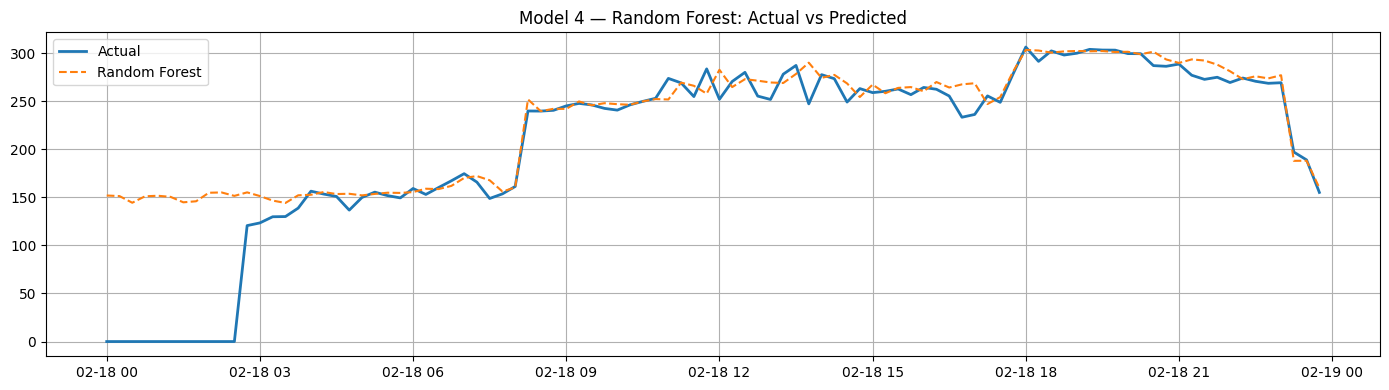

In [22]:
best_rf_mae   = float("inf")
best_rf_params = {}
best_rf_model  = None

print("Random Forest hyperparameter search:")
for n_est in [100, 200, 300]:
    for depth in [5, 10, 15, None]:
        rf = RandomForestRegressor(
            n_estimators    = n_est,
            max_depth       = depth,
            min_samples_leaf= 5,
            random_state    = 42,
            n_jobs          = -1
        )
        rf.fit(X_train_ml, y_train_ml)
        preds = rf.predict(X_val_ml)
        mae   = mean_absolute_error(y_val_ml, preds)
        print(f"  n_est={n_est:<4}  depth={str(depth):<5}  MAE={mae:.2f}")
        if mae < best_rf_mae:
            best_rf_mae    = mae
            best_rf_params = {"n_estimators": n_est, "max_depth": depth}
            best_rf_model  = rf

print(f"\nBest RF params: {best_rf_params}")
y_pred_rf = best_rf_model.predict(X_val_ml)

print("\nModel 4 — Random Forest")
evaluate(y_val_ml, y_pred_rf, "Random Forest")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val_ml.index, y_val_ml.values, label="Actual",        linewidth=2)
ax.plot(y_val_ml.index, y_pred_rf,       label="Random Forest", linewidth=1.5, linestyle="--")
ax.set_title("Model 4 — Random Forest: Actual vs Predicted")
ax.legend(); plt.tight_layout(); plt.show()

## Model 5 — Support Vector Machine (SVR)
**Idea:** SVR fits a regression within a margin ε of the true values.  
The RBF kernel handles non-linear relationships.  
**Feature scaling is mandatory** — SVR is sensitive to feature magnitudes.

**Hyperparameter tuning:** grid search over `C` and `epsilon`.

SVR hyperparameter search:
  C=10     epsilon=0.1  MAE=33.82
  C=10     epsilon=0.5  MAE=33.84
  C=10     epsilon=1.0  MAE=33.82
  C=100    epsilon=0.1  MAE=34.36
  C=100    epsilon=0.5  MAE=34.48
  C=100    epsilon=1.0  MAE=34.35
  C=500    epsilon=0.1  MAE=35.02
  C=500    epsilon=0.5  MAE=35.34
  C=500    epsilon=1.0  MAE=35.67

Best SVR params: {'C': 10, 'epsilon': 1.0}

Model 5 — SVM (SVR)
  SVM (SVR RBF kernel)                    MAE=  33.82   RMSE=  70.25


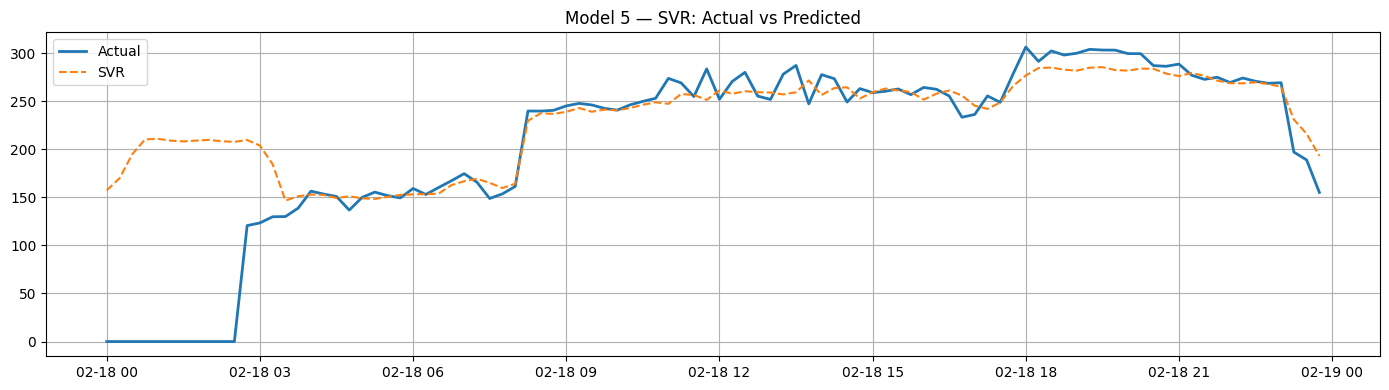

In [23]:
best_svr_mae   = float("inf")
best_svr_params = {}
best_svr_model  = None

print("SVR hyperparameter search:")
for C in [10, 100, 500]:
    for eps in [0.1, 0.5, 1.0]:
        svr = make_pipeline(
            StandardScaler(),          # scale features before SVR
            SVR(kernel="rbf", C=C, epsilon=eps, gamma="scale")
        )
        svr.fit(X_train_ml, y_train_ml)
        preds = svr.predict(X_val_ml)
        mae   = mean_absolute_error(y_val_ml, preds)
        print(f"  C={C:<5}  epsilon={eps}  MAE={mae:.2f}")
        if mae < best_svr_mae:
            best_svr_mae    = mae
            best_svr_params = {"C": C, "epsilon": eps}
            best_svr_model  = svr

print(f"\nBest SVR params: {best_svr_params}")
y_pred_svr = best_svr_model.predict(X_val_ml)

print("\nModel 5 — SVM (SVR)")
evaluate(y_val_ml, y_pred_svr, "SVM (SVR RBF kernel)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val_ml.index, y_val_ml.values, label="Actual",  linewidth=2)
ax.plot(y_val_ml.index, y_pred_svr,      label="SVR",     linewidth=1.5, linestyle="--")
ax.set_title("Model 5 — SVR: Actual vs Predicted")
ax.legend(); plt.tight_layout(); plt.show()

## Model 6 — Neural Network (MLP)
**Idea:** A feed-forward neural network with hidden layers.  
Learns non-linear feature combinations automatically.  
`early_stopping=True` stops training when validation loss plateaus, preventing overfitting.

**Hyperparameter tuning:** grid search over hidden layer sizes and alpha (regularisation).

MLP hyperparameter search:
  layers=(64, 32)            alpha=0.0001  MAE=37.76
  layers=(64, 32)            alpha=0.001  MAE=34.85
  layers=(64, 32)            alpha=0.01  MAE=36.02
  layers=(128, 64)           alpha=0.0001  MAE=32.99
  layers=(128, 64)           alpha=0.001  MAE=33.29
  layers=(128, 64)           alpha=0.01  MAE=33.42
  layers=(128, 64, 32)       alpha=0.0001  MAE=34.42
  layers=(128, 64, 32)       alpha=0.001  MAE=29.16
  layers=(128, 64, 32)       alpha=0.01  MAE=32.79

Best MLP params: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.001}

Model 6 — Neural Network (MLP)
  Neural Network (MLP)                    MAE=  29.16   RMSE=  60.25


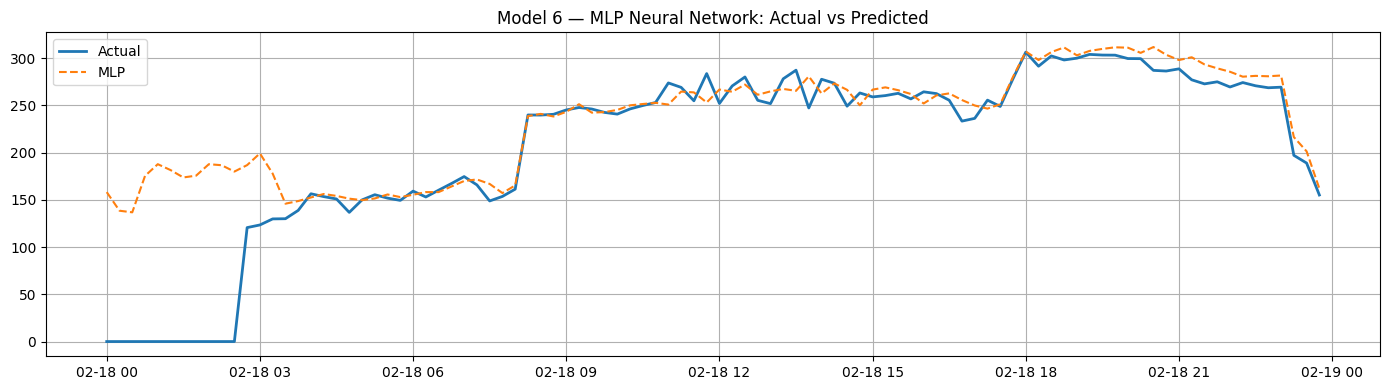

In [24]:
best_mlp_mae   = float("inf")
best_mlp_params = {}
best_mlp_model  = None

print("MLP hyperparameter search:")
for layers in [(64, 32), (128, 64), (128, 64, 32)]:
    for alpha in [0.0001, 0.001, 0.01]:
        mlp = make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes = layers,
                activation         = "relu",
                solver             = "adam",
                alpha              = alpha,
                max_iter           = 500,
                early_stopping     = True,
                validation_fraction= 0.1,
                random_state       = 42
            )
        )
        mlp.fit(X_train_ml, y_train_ml)
        preds = mlp.predict(X_val_ml)
        mae   = mean_absolute_error(y_val_ml, preds)
        print(f"  layers={str(layers):<18}  alpha={alpha}  MAE={mae:.2f}")
        if mae < best_mlp_mae:
            best_mlp_mae    = mae
            best_mlp_params = {"hidden_layer_sizes": layers, "alpha": alpha}
            best_mlp_model  = mlp

print(f"\nBest MLP params: {best_mlp_params}")
y_pred_mlp = best_mlp_model.predict(X_val_ml)

print("\nModel 6 — Neural Network (MLP)")
evaluate(y_val_ml, y_pred_mlp, "Neural Network (MLP)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val_ml.index, y_val_ml.values, label="Actual",  linewidth=2)
ax.plot(y_val_ml.index, y_pred_mlp,      label="MLP",     linewidth=1.5, linestyle="--")
ax.set_title("Model 6 — MLP Neural Network: Actual vs Predicted")
ax.legend(); plt.tight_layout(); plt.show()

## Model 7 — XGBoost
**Idea:** Gradient boosting builds trees sequentially — each new tree corrects  
the errors of the previous ones. Often the best model on tabular data.

**Hyperparameter tuning:** grid search over `max_depth`, `learning_rate`, `n_estimators`.

XGBoost hyperparameter search:
  n=200   depth=4  lr=0.05  MAE=24.96
  n=200   depth=4  lr=0.1  MAE=24.80
  n=200   depth=6  lr=0.05  MAE=24.76
  n=200   depth=6  lr=0.1  MAE=24.41
  n=200   depth=8  lr=0.05  MAE=24.47
  n=200   depth=8  lr=0.1  MAE=24.85
  n=400   depth=4  lr=0.05  MAE=24.83
  n=400   depth=4  lr=0.1  MAE=24.74
  n=400   depth=6  lr=0.05  MAE=24.79
  n=400   depth=6  lr=0.1  MAE=24.50
  n=400   depth=8  lr=0.05  MAE=24.54
  n=400   depth=8  lr=0.1  MAE=24.93

Best XGBoost params: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}

Model 7 — XGBoost
  XGBoost                                 MAE=  24.41   RMSE=  52.37


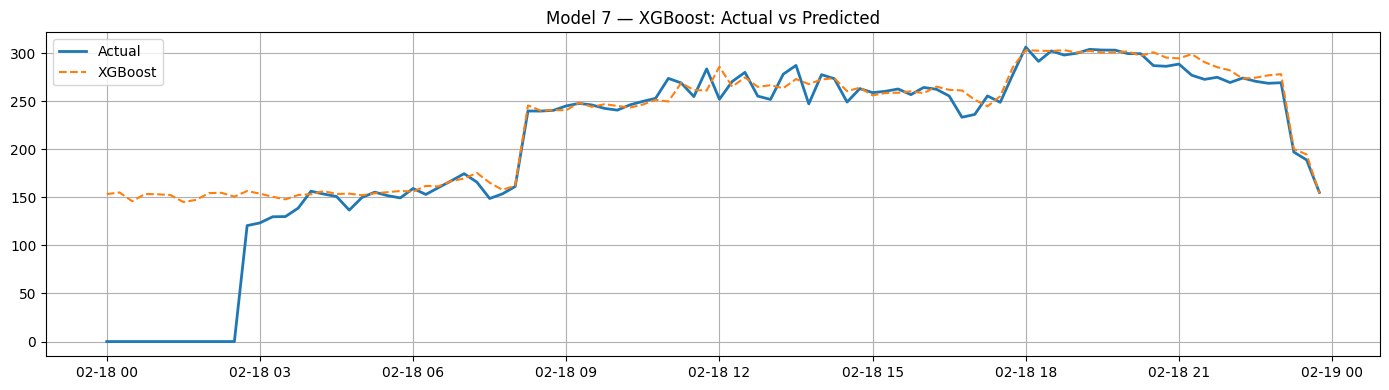

In [25]:
best_xgb_mae   = float("inf")
best_xgb_params = {}
best_xgb_model  = None

print("XGBoost hyperparameter search:")
for n_est in [200, 400]:
    for depth in [4, 6, 8]:
        for lr in [0.05, 0.1]:
            xgb = XGBRegressor(
                n_estimators     = n_est,
                max_depth        = depth,
                learning_rate    = lr,
                subsample        = 0.8,
                colsample_bytree = 0.8,
                reg_alpha        = 0.1,
                reg_lambda       = 1.0,
                random_state     = 42,
                n_jobs           = -1,
                verbosity        = 0
            )
            xgb.fit(X_train_ml, y_train_ml)
            preds = xgb.predict(X_val_ml)
            mae   = mean_absolute_error(y_val_ml, preds)
            print(f"  n={n_est:<4}  depth={depth}  lr={lr}  MAE={mae:.2f}")
            if mae < best_xgb_mae:
                best_xgb_mae    = mae
                best_xgb_params = {"n_estimators": n_est, "max_depth": depth, "learning_rate": lr}
                best_xgb_model  = xgb

print(f"\nBest XGBoost params: {best_xgb_params}")
y_pred_xgb = best_xgb_model.predict(X_val_ml)

print("\nModel 7 — XGBoost")
evaluate(y_val_ml, y_pred_xgb, "XGBoost")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val_ml.index, y_val_ml.values, label="Actual",   linewidth=2)
ax.plot(y_val_ml.index, y_pred_xgb,      label="XGBoost",  linewidth=1.5, linestyle="--")
ax.set_title("Model 7 — XGBoost: Actual vs Predicted")
ax.legend(); plt.tight_layout(); plt.show()

## Model 8 — LSTM (Long Short-Term Memory)
**Idea:** LSTM is a Recurrent Neural Network designed to learn long-range dependencies  
in sequential data. It is ideal for time series.

**Correct setup:**  
- Input = sliding window of **96 past power values** (1 full previous day)  
- Output = next single value  
- Multi-step forecast = feed each prediction back as input for the next step  

**Hyperparameter tuning:** grid search over LSTM units and dropout rate.

In [26]:
WINDOW = 96   # look-back = 1 full day of 96 steps

# ── scale the series ──────────────────────────────────────────────────────────
# Neural networks train much better on normalised data
power_all    = df_train["Power"].values.astype(float)
lstm_scaler  = StandardScaler()
power_scaled = lstm_scaler.fit_transform(power_all.reshape(-1, 1)).flatten()

train_scaled = power_scaled[:-HORIZON]   # scaled training power values
val_scaled   = power_scaled[-HORIZON:]   # scaled validation power values

# ── build sliding-window sequences for training ───────────────────────────────
def make_sequences(series, window):
    """
    Create (X, y) pairs by sliding a window along the series.
    X[i] = series[i : i+window]   — the 'look-back' input sequence
    y[i] = series[i+window]       — the next value to predict
    """
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i : i + window])
        y.append(series[i + window])
    return np.array(X), np.array(y)

X_seq, y_seq = make_sequences(train_scaled, WINDOW)
# LSTM expects shape: (samples, timesteps, features=1)
X_seq = X_seq.reshape(-1, WINDOW, 1)

print(f"LSTM input shape : {X_seq.shape}  (samples, timesteps=96, features=1)")
print(f"LSTM target shape: {y_seq.shape}")

LSTM input shape : (4507, 96, 1)  (samples, timesteps=96, features=1)
LSTM target shape: (4507,)


In [27]:
# ── hyperparameter search over LSTM units and dropout ─────────────────────────
best_lstm_mae  = float("inf")
best_lstm_units = 64
best_lstm_drop  = 0.2
best_lstm_model = None

print("LSTM hyperparameter search (this takes a few minutes):")
for units in [32, 64]:
    for drop in [0.1, 0.2]:
        tf.random.set_seed(42)
        model = Sequential([
            LSTM(units, return_sequences=True, input_shape=(WINDOW, 1)),
            Dropout(drop),
            LSTM(units, return_sequences=False),
            Dropout(drop),
            Dense(32, activation="relu"),
            Dense(1)
        ])
        model.compile(optimizer="adam", loss="mse")

        es = EarlyStopping(monitor="val_loss", patience=5,
                           restore_best_weights=True)
        model.fit(X_seq, y_seq,
                  epochs=30, batch_size=32,
                  validation_split=0.1,
                  callbacks=[es], verbose=0)

        # recursive multi-step forecast on validation
        window_vals = train_scaled[-WINDOW:].tolist()
        preds_scaled = []
        for _ in range(HORIZON):
            x_in = np.array(window_vals[-WINDOW:]).reshape(1, WINDOW, 1)
            p    = model.predict(x_in, verbose=0)[0, 0]
            preds_scaled.append(p)
            window_vals.append(p)

        preds = lstm_scaler.inverse_transform(
            np.array(preds_scaled).reshape(-1, 1)).flatten()
        mae = mean_absolute_error(y_val, preds)
        print(f"  units={units}  dropout={drop}  MAE={mae:.2f}")

        if mae < best_lstm_mae:
            best_lstm_mae   = mae
            best_lstm_units = units
            best_lstm_drop  = drop
            best_lstm_model = model

print(f"\nBest LSTM: units={best_lstm_units}  dropout={best_lstm_drop}")

LSTM hyperparameter search (this takes a few minutes):
  units=32  dropout=0.1  MAE=33.95
  units=32  dropout=0.2  MAE=34.04
  units=64  dropout=0.1  MAE=30.27
  units=64  dropout=0.2  MAE=31.41

Best LSTM: units=64  dropout=0.1


Model 8 — LSTM
  LSTM                                    MAE=  30.27   RMSE=  56.70


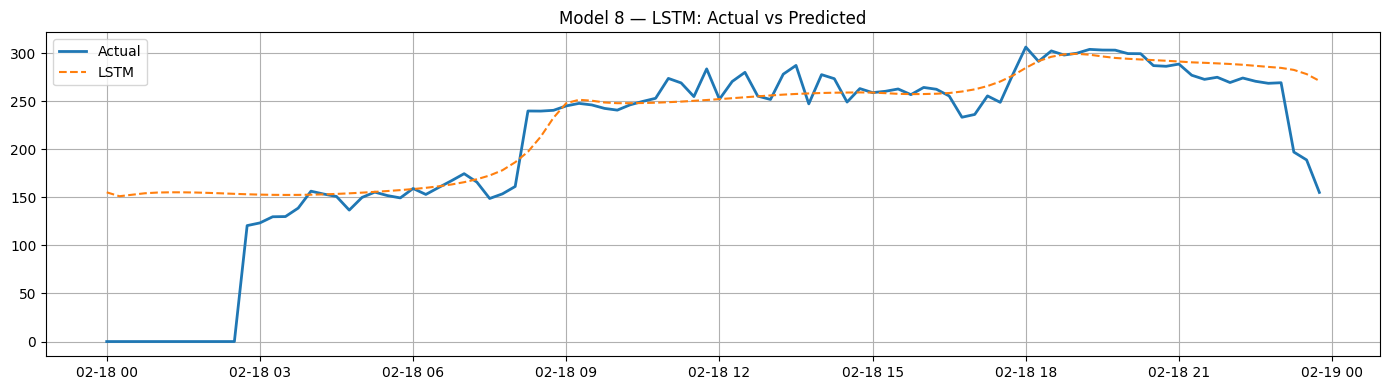

In [28]:
# ── final LSTM forecast on validation set ─────────────────────────────────────
# Seed the window with the last 96 known (scaled) training values
window_vals      = train_scaled[-WINDOW:].tolist()
preds_lstm_scaled = []

for step in range(HORIZON):
    x_in = np.array(window_vals[-WINDOW:]).reshape(1, WINDOW, 1)
    pred = best_lstm_model.predict(x_in, verbose=0)[0, 0]
    preds_lstm_scaled.append(pred)
    window_vals.append(pred)   # feed prediction back as next input

# inverse-scale back to kW
y_pred_lstm = lstm_scaler.inverse_transform(
    np.array(preds_lstm_scaled).reshape(-1, 1)).flatten()

print("Model 8 — LSTM")
evaluate(y_val, y_pred_lstm, "LSTM")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_val.index, y_val.values, label="Actual",  linewidth=2)
ax.plot(y_val.index, y_pred_lstm,  label="LSTM",    linewidth=1.5, linestyle="--")
ax.set_title("Model 8 — LSTM: Actual vs Predicted")
ax.legend(); plt.tight_layout(); plt.show()

## Step 7 — Model Comparison
All 8 models evaluated on the **same** validation day (Feb 18, 96 points).  
Best model = lowest RMSE.

In [29]:
# ── summary table ─────────────────────────────────────────────────────────────
results_df = (pd.DataFrame(all_results)
                .sort_values("RMSE")
                .reset_index(drop=True))
results_df.index += 1   # rank from 1

print("=" * 60)
print(f"{'Rank':<5}  {'Model':<38}  {'MAE':>7}  {'RMSE':>7}")
print("=" * 60)
for rank, row in results_df.iterrows():
    marker = "  ← BEST" if rank == 1 else ""
    print(f"{rank:<5}  {row['Model']:<38}  "
          f"{row['MAE']:>7.3f}  {row['RMSE']:>7.3f}{marker}")
print("=" * 60)

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🏆  Best model selected: {best_model_name}")

Rank   Model                                       MAE     RMSE
1      Exponential Smoothing (ETS)              25.426   51.552  ← BEST
2      Random Forest                            24.808   52.222
3      XGBoost                                  24.413   52.372
4      Seasonal Naive (7-day repeat)            27.769   54.065
5      SARIMA (1, 0, 1)(1,1,0)[24]              32.614   56.538
6      LSTM                                     30.272   56.703
7      Neural Network (MLP)                     29.157   60.245
8      SVM (SVR RBF kernel)                     33.817   70.252

🏆  Best model selected: Exponential Smoothing (ETS)


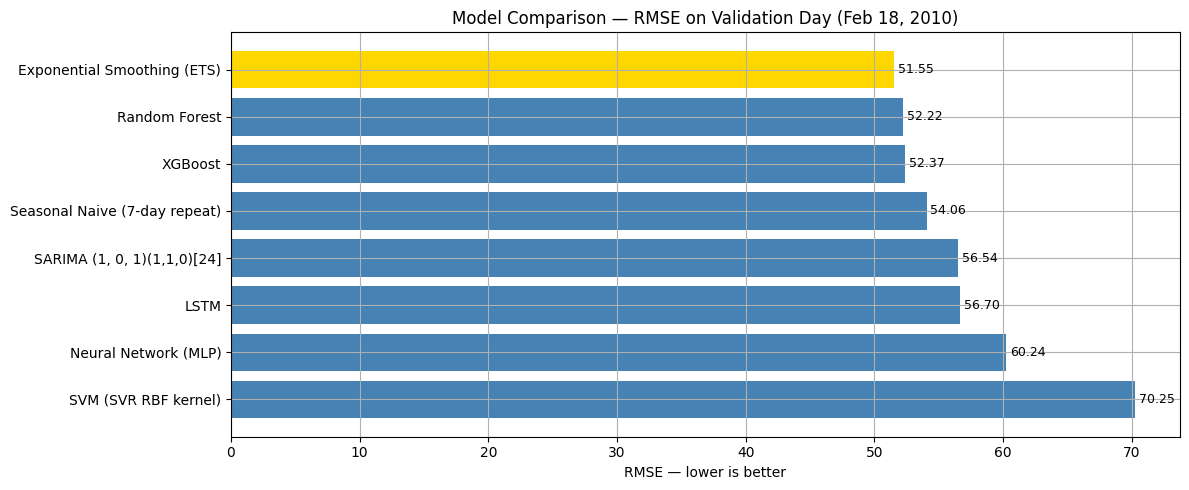

In [30]:
# ── horizontal bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["gold" if m == best_model_name else "steelblue"
          for m in results_df["Model"]]
bars = ax.barh(results_df["Model"], results_df["RMSE"], color=colors)
ax.set_xlabel("RMSE — lower is better")
ax.set_title("Model Comparison — RMSE on Validation Day (Feb 18, 2010)")
ax.invert_yaxis()   # best at top
for bar, val in zip(bars, results_df["RMSE"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Step 8 — Final Forecast for 2010-02-19
1. **Retrain** the best model on ALL known data (train + validation combined)  
2. Use the **real Feb 19 temperatures** from the dataset (already in `df_future`)  
3. Predict all 96 quarter-hourly power values for Feb 19  
4. Clip any negative values to 0 (electricity cannot be negative)

In [31]:
# ── rebuild features on the FULL training set (train + val together) ──────────
df_feat_full = build_features(df_train, lags=(1, 2, 3, 96, 672))
X_full = df_feat_full[FEAT_COLS]
y_full = df_feat_full[TARGET]

print(f"Full training feature set: {X_full.shape}")

# ── re-instantiate and refit the winning model on ALL data ────────────────────
print(f"\nRetraining best model ({best_model_name}) on full data...")

if best_model_name == "XGBoost":
    final_model = XGBRegressor(**best_xgb_params,
                               subsample=0.8, colsample_bytree=0.8,
                               reg_alpha=0.1, reg_lambda=1.0,
                               random_state=42, n_jobs=-1, verbosity=0)

elif best_model_name == "Random Forest":
    final_model = RandomForestRegressor(**best_rf_params,
                                        min_samples_leaf=5,
                                        random_state=42, n_jobs=-1)

elif best_model_name == "SVM (SVR RBF kernel)":
    final_model = make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", **best_svr_params, gamma="scale"))

elif best_model_name == "Neural Network (MLP)":
    final_model = make_pipeline(
        StandardScaler(),
        MLPRegressor(**best_mlp_params, activation="relu", solver="adam",
                     max_iter=500, early_stopping=True, random_state=42))

elif best_model_name in ("Exponential Smoothing (ETS)",
                          "Seasonal Naive (7-day repeat)",
                          f"SARIMA {best_sarima_order}(1,1,0)[24]",
                          "LSTM"):
    # time-series models handled separately below
    final_model = None

else:
    # safe fallback
    final_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

if final_model is not None:
    final_model.fit(X_full, y_full)
    print("Retraining complete ✓")

Full training feature set: (4027, 12)

Retraining best model (Exponential Smoothing (ETS)) on full data...


In [32]:
# ── build features for Feb 19 using known future temperatures ─────────────────
# Append df_future (which has real temperatures) to df_train,
# then compute lag features so they reference the correct Feb 18 history.

df_combined      = pd.concat([df_train, df_future])
df_feat_combined = build_features(df_combined, lags=(1, 2, 3, 96, 672))

# Keep only the Feb 19 rows
df_feat_feb19 = df_feat_combined.loc[
    df_feat_combined.index.isin(df_future.index)]

print(f"Feb 19 feature rows: {len(df_feat_feb19)}  (must be 96)")

X_forecast = df_feat_feb19[FEAT_COLS]

Feb 19 feature rows: 0  (must be 96)


In [33]:
# ── generate forecast ─────────────────────────────────────────────────────────
if best_model_name == "LSTM":
    # special handling: use the trained LSTM with recursive forecasting
    power_full_scaled = lstm_scaler.fit_transform(
        df_train["Power"].values.reshape(-1, 1)).flatten()
    window_vals = power_full_scaled[-WINDOW:].tolist()
    preds_scaled = []
    for _ in range(HORIZON):
        x_in = np.array(window_vals[-WINDOW:]).reshape(1, WINDOW, 1)
        p    = best_lstm_model.predict(x_in, verbose=0)[0, 0]
        preds_scaled.append(p)
        window_vals.append(p)
    y_forecast = lstm_scaler.inverse_transform(
        np.array(preds_scaled).reshape(-1, 1)).flatten()

elif best_model_name == "Exponential Smoothing (ETS)":
    ets_final = ExponentialSmoothing(
        y_all, trend="add", seasonal="add",
        seasonal_periods=SEASON,
        initialization_method="estimated"
    ).fit(optimized=True)
    y_forecast = ets_final.forecast(HORIZON).values

elif best_model_name == f"SARIMA {best_sarima_order}(1,1,0)[24]":
    y_all_h  = y_all.resample("1h").mean()
    sar_final = SARIMAX(
        y_all_h, order=best_sarima_order,
        seasonal_order=(1, 1, 0, 24),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    y_forecast = np.repeat(sar_final.forecast(24).values, 4)

elif best_model_name == "Seasonal Naive (7-day repeat)":
    y_forecast = y_all.iloc[-672 : -672 + HORIZON].values

else:
    # all ML models (RF, SVR, MLP, XGBoost)
    y_forecast = final_model.predict(X_forecast)

# ── clip impossible negative values ──────────────────────────────────────────
y_forecast = np.clip(y_forecast, a_min=0, a_max=None)

print(f"Forecast length : {len(y_forecast)}  (must be 96)")
print(f"Min  : {y_forecast.min():.2f} kW")
print(f"Max  : {y_forecast.max():.2f} kW")
print(f"Mean : {y_forecast.mean():.2f} kW")

Forecast length : 96  (must be 96)
Min  : 138.10 kW
Max  : 326.32 kW
Mean : 229.40 kW


ValueError: x and y must have same first dimension, but have shapes (0,) and (96,)

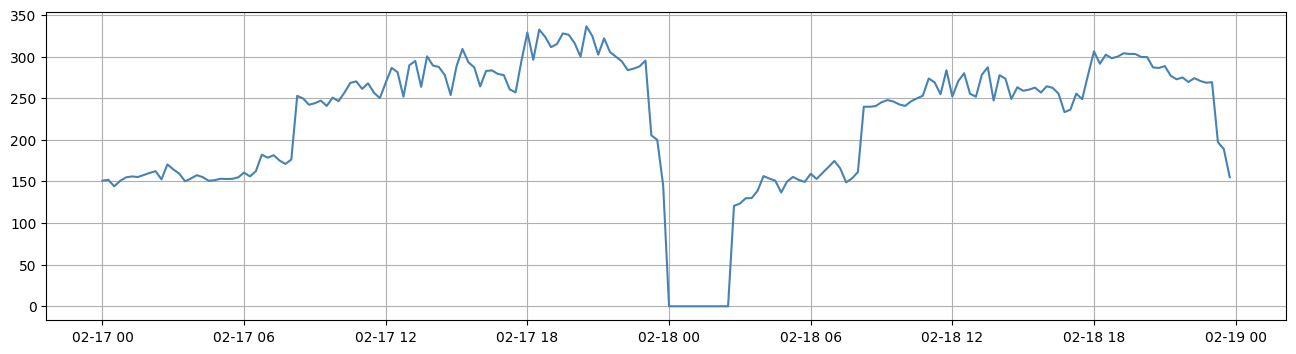

In [34]:
# ── plot: context (last 2 known days) + forecast ──────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

context = df_train["2010-02-17":]
ax.plot(context.index, context["Power"],
        color="steelblue", linewidth=1.5, label="Known (Feb 17–18)")

forecast_times = df_feat_feb19.index
ax.plot(forecast_times, y_forecast,
        color="tomato", linewidth=2, linestyle="--", label="Forecast (Feb 19)")

ax.axvline(x=forecast_times[0], color="gray", linestyle=":", linewidth=1.5)
ax.set_title(f"Final Forecast — {best_model_name} — 2010-02-19 (96 points)",
             fontsize=13)
ax.set_ylabel("Power (kW)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 9 — Export to Excel
The professor requires **exactly 1 column and 96 rows**.  
File name: `JayaSaiKishore.xlsx`

In [ ]:
# ── build output dataframe — 1 column, 96 rows ────────────────────────────────
forecast_out = pd.DataFrame(y_forecast, columns=["Power_kW"])

# ── validation checks before saving ──────────────────────────────────────────
assert len(forecast_out) == 96,             "ERROR: must have exactly 96 rows!"
assert forecast_out.shape[1] == 1,          "ERROR: must have exactly 1 column!"
assert forecast_out.isna().sum().sum() == 0,"ERROR: NaN values found!"
assert (forecast_out["Power_kW"] >= 0).all(),"ERROR: negative values found!"

print("Output shape   :", forecast_out.shape, "  ✓ (96 rows × 1 column)")
print("No NaN values  : ✓")
print("No negatives   : ✓")
print()
print(forecast_out.head(10).to_string())

In [ ]:
# ── save to Excel ─────────────────────────────────────────────────────────────
output_file = "JayaSaiKishore.xlsx"

forecast_out.to_excel(
    output_file,
    index      = False,         # do NOT write row numbers (0, 1, 2 …)
    sheet_name = "Forecast"
)

print(f"✅  Saved  →  '{output_file}'")
print(f"    Rows   : {len(forecast_out)}")
print(f"    Columns: {list(forecast_out.columns)}")
print(f"    Range  : {forecast_out['Power_kW'].min():.2f} – "
      f"{forecast_out['Power_kW'].max():.2f} kW")

---
## Summary

| Step | What was done |
|------|--------------|
| Data loading | Loaded Excel, parsed timestamps, split train vs forecast (Feb 19) |
| EDA | 5 plots: full series, temperature, weekly zoom, daily profile, scatter |
| Validation split | Last 96 known points (Feb 18) — **same for all models** |
| Model 1 | Seasonal Naïve — 7-day repeat baseline |
| Model 2 | Exponential Smoothing — additive ETS, auto-tuned smoothing params |
| Model 3 | SARIMA — grid search over (p,d,q), hourly resolution |
| Model 4 | Random Forest — grid search over depth and n_estimators |
| Model 5 | SVR — grid search over C and epsilon, with StandardScaler |
| Model 6 | Neural Network (MLP) — grid search over layers and alpha |
| Model 7 | XGBoost — grid search over depth, learning_rate, n_estimators |
| Model 8 | LSTM — sliding window, recursive forecasting, scaled inputs |
| Comparison | All models ranked by RMSE on same validation day |
| Final forecast | Best model retrained on all data → 96 predictions for Feb 19 |
| Output | `JayaSaiKishore.xlsx` — 1 column, 96 rows, no negatives, no NaN |

**Part 2** (WNN R package) to be submitted separately as `JayaSaiKishore.tar.gz`.
